In [1]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import logging 
import warnings 
import seaborn as sns 
from pathlib import Path 

warnings.filterwarnings("ignore")

# STYLE 
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

COLORS = sns.color_palette("husl", 12)

def comp_path() -> Path:
    COMPETITION_SLUG = "rsna-knee-abnormality-detection"
    COMPETITION_CANDIDATES = [
        Path(f"/kaggle/input/competitions/{COMPETITION_SLUG}"),
        Path(f"/kaggle/input/{COMPETITION_SLUG}"),
    ]

    for root in COMPETITION_CANDIDATES:
        if root.exists():
            return root 
    raise FileNotFoundError(
        "Add rsna-knee-abnormality-detection as data input in notebook settings"
    )

DATA_DIR = comp_path()
print(f"Competition Directory: {DATA_DIR}")
print(f"Contents: \n{sorted(f.name for f in DATA_DIR.iterdir())}")
TARGETS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture"
]

print("Setup Complete!")

Competition Directory: /kaggle/input/competitions/rsna-knee-abnormality-detection
Contents: 
['sample_submission.csv', 'test.csv', 'test_series', 'test_series.csv', 'train.csv', 'train_series', 'train_series.csv']
Setup Complete!


# Overview Data

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
train_series_df = pd.read_csv(DATA_DIR / "train_series.csv")
test_series_df = pd.read_csv(DATA_DIR / "test_series.csv")
sample_sub_df = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("=" * 120)
print("DATASET SUMMARY")
print("="  * 120)
print(f"train.csv:                                {train_df.shape[0]:,} rows x {train_df.shape[1]} cols")
print(f"test.csv:                                 {test_df.shape[0]:,} rows x {test_df.shape[1]} cols")
print(f"train_series.csv:                         {train_series_df.shape[0]:,} rows x {train_series_df.shape[1]} cols")
print(f"test_series.csv:                          {test_series_df.shape[0]:,} rows x {test_series_df.shape[1]} cols")
print(f"sample_sub.csv:                           {sample_sub_df.shape[0]:,} rows x {sample_sub_df.shape[1]} cols")

# Count Dicom Files
train_dcm_dir = DATA_DIR / "train_series"
test_dcm_dir = DATA_DIR / "test_series"

train_studies = sorted(train_dcm_dir.iterdir()) if train_dcm_dir.exists() else []
test_studies = sorted(test_dcm_dir.iterdir())  if test_dcm_dir.exists() else []

print(f"Train (Studies):                          {len(train_studies)}")
print(f"Test (Studies):                           {len(test_studies)}")

DATASET SUMMARY
train.csv:                                4,407 rows x 14 cols
test.csv:                                 3 rows x 1 cols
train_series.csv:                         24,371 rows x 5 cols
test_series.csv:                          15 rows x 5 cols
sample_sub.csv:                           3 rows x 13 cols
Train (Studies):                          4407
Test (Studies):                           3


In [3]:
# Submission Format
print("=" * 60)
print("Sample Submission -> sample_submission.csv")
print("=" * 60) 

display(sample_sub_df.head(15))
print(f"\nPrediction Columns: \n{[c for c in sample_sub_df.columns if c != "StudyInstanceUID"]}")

Sample Submission -> sample_submission.csv


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5



Prediction Columns: 
['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


Target Columns: 12 
['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']

Labelled Data: 58 / 4407 (1.32%)
Unlabelled Data: 4,349


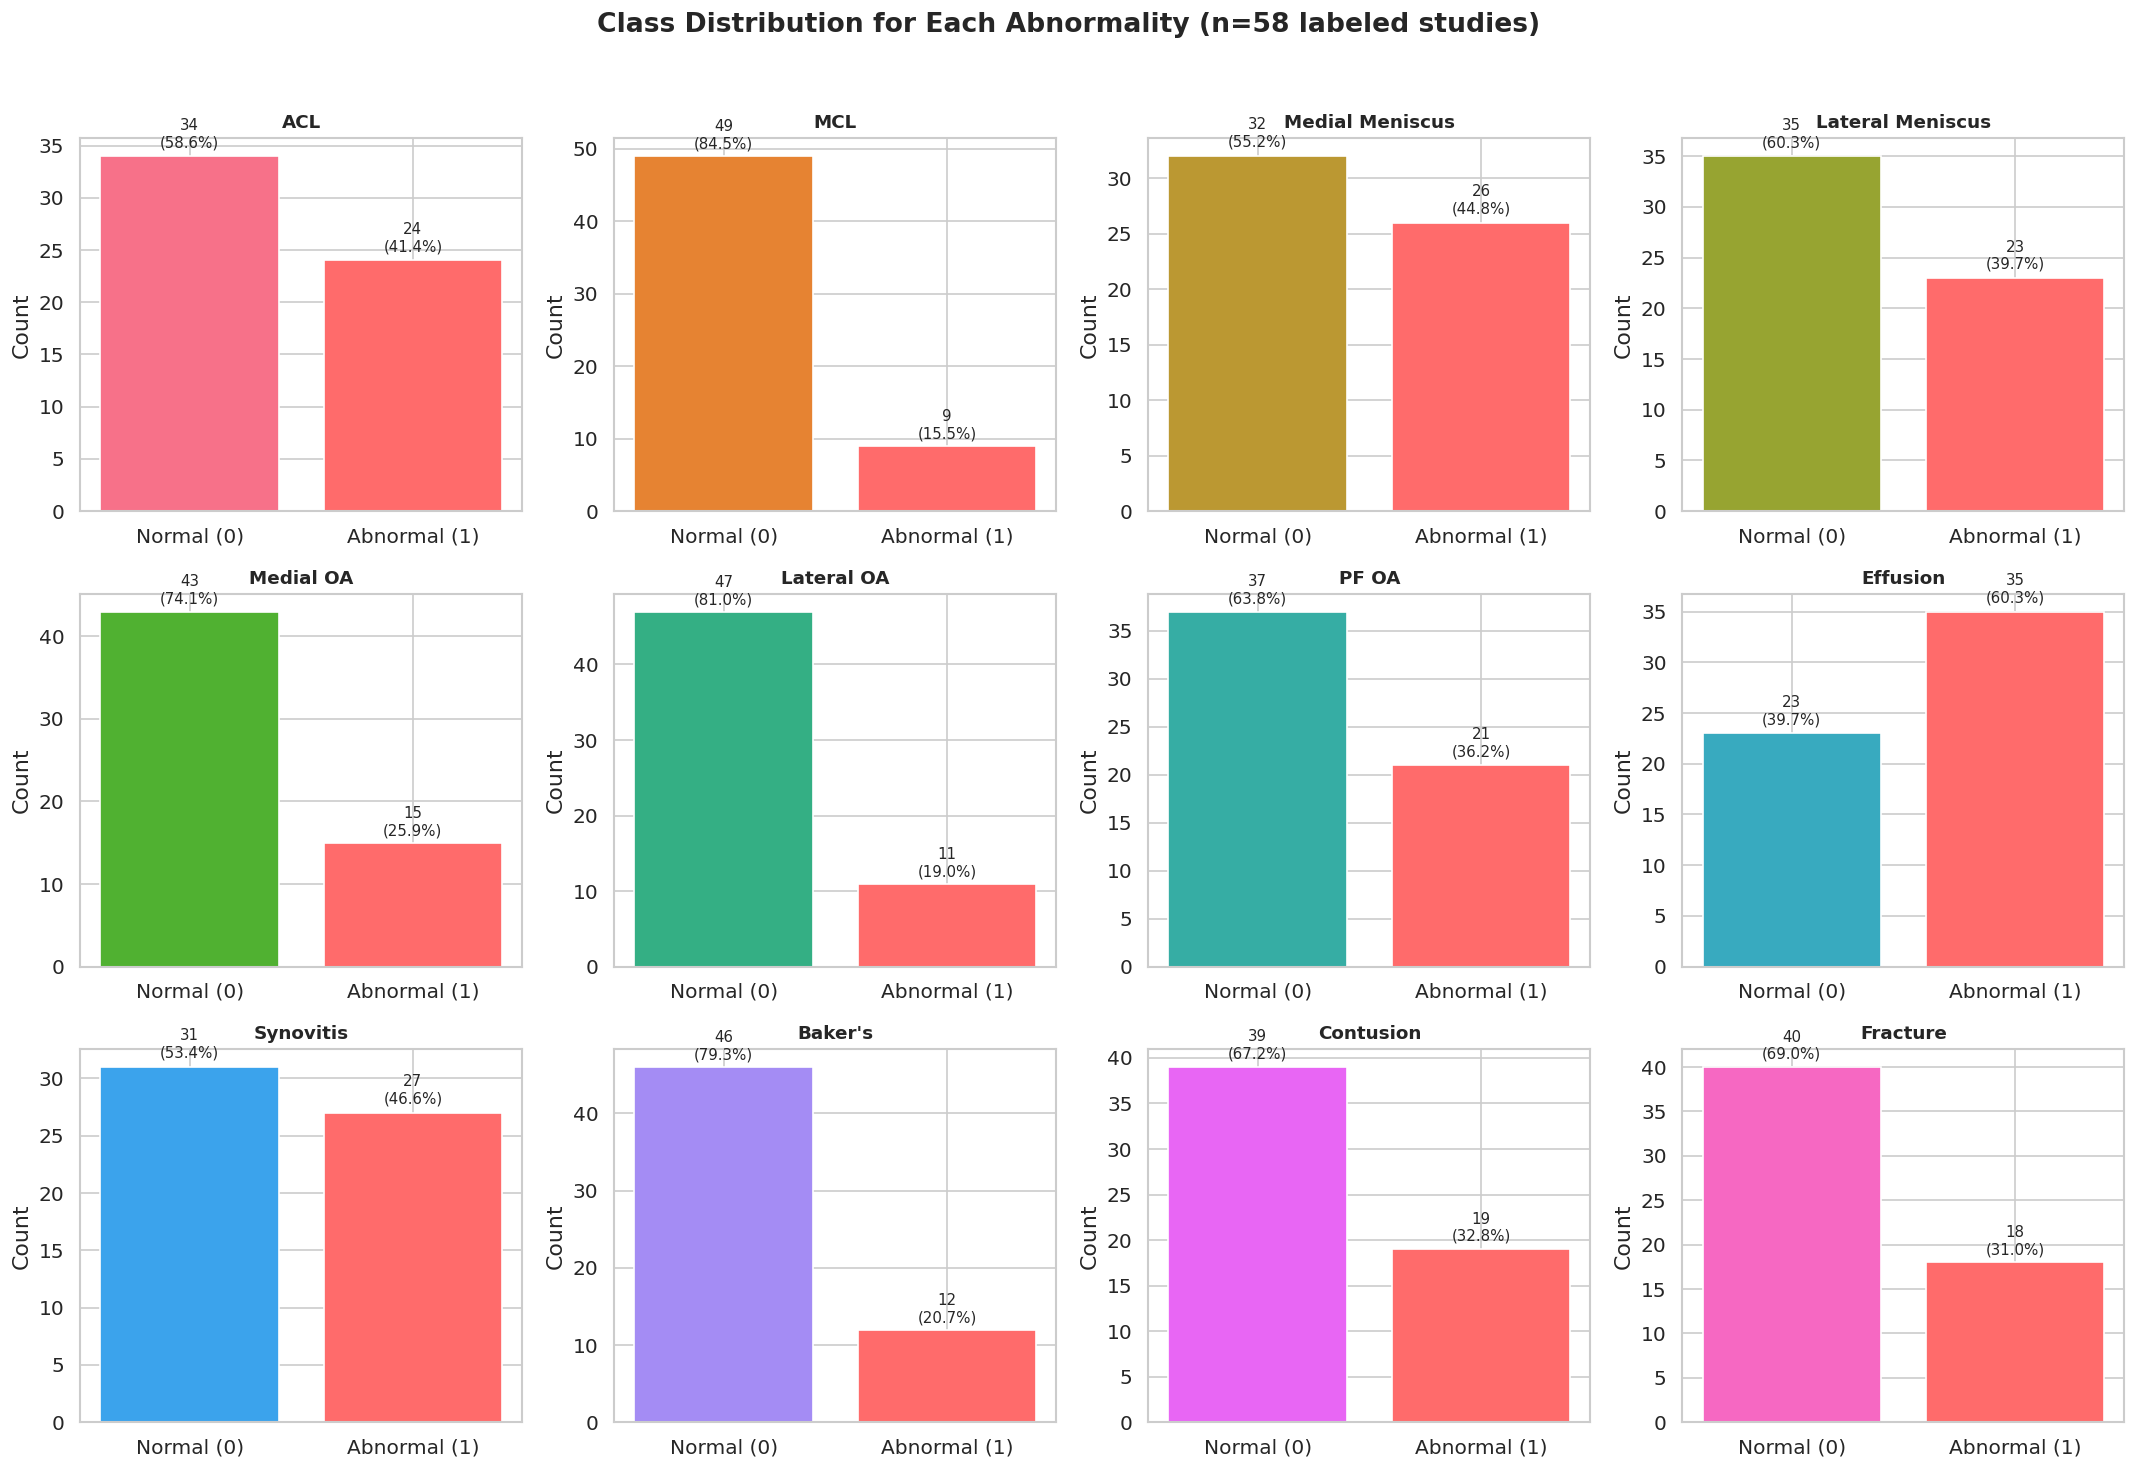

In [4]:
target_cols = [c for c in train_df.columns if c not in ("StudyInstanceUID", "Report")]
print(f"Target Columns: {len(target_cols)} \n{target_cols}")

# Filter NAN 
labelled_df = train_df.dropna(subset=target_cols, how = "all").copy()
print(f"\nLabelled Data: {len(labelled_df)} / {len(train_df)} ({(len(labelled_df) / len(train_df)) * 100:.2f}%)")
print(f"Unlabelled Data: {len(train_df) - len(labelled_df):,}")

# Data Vizualization 
fig, axes = plt.subplots(3, 4, figsize = (18, 12))
fig.suptitle(f"Class Distribution for Each Abnormality (n={len(labelled_df)} labeled studies)", 
             fontsize=16, fontweight='bold', y=1.02)

for idx, (col, ax) in enumerate(zip(target_cols, axes.ravel())):
    counts = labelled_df[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color = [COLORS[idx], "#ff6b6b"])

    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{val}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)

    ax.set_title(col, fontweight = "bold", fontsize = 11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal (0)", "Abnormal (1)"])

plt.tight_layout()
plt.show()
    

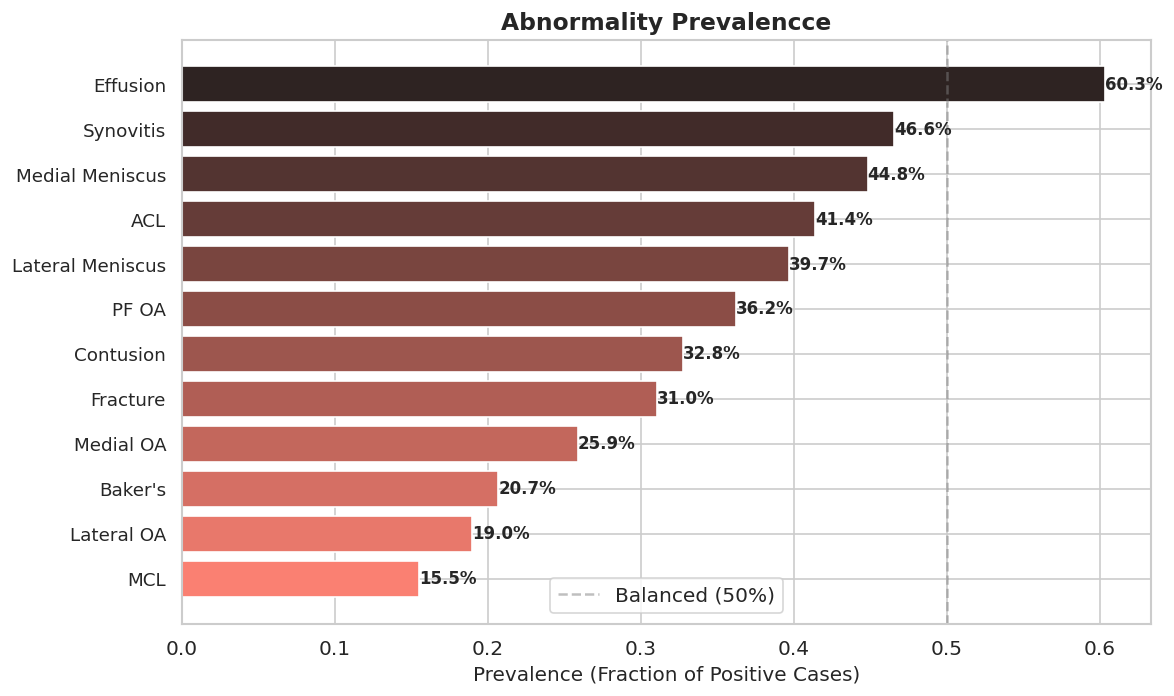


Imbalance Ratio (positive:negative):
     MCL                 : 49.0 : 9.0  (ratio 5.4:1)
     Lateral OA          : 47.0 : 11.0  (ratio 4.3:1)
     Baker's             : 46.0 : 12.0  (ratio 3.8:1)
     Medial OA           : 43.0 : 15.0  (ratio 2.9:1)
     Fracture            : 40.0 : 18.0  (ratio 2.2:1)
     Contusion           : 39.0 : 19.0  (ratio 2.1:1)
     PF OA               : 37.0 : 21.0  (ratio 1.8:1)
     Lateral Meniscus    : 35.0 : 23.0  (ratio 1.5:1)
     ACL                 : 34.0 : 24.0  (ratio 1.4:1)
     Medial Meniscus     : 32.0 : 26.0  (ratio 1.2:1)
     Synovitis           : 31.0 : 27.0  (ratio 1.1:1)
     Effusion            : 23.0 : 35.0  (ratio 0.7:1)


In [5]:
# Abnormalities Location 
prevalence = labelled_df[target_cols].mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10,6))
bras = ax.barh(range(len(prevalence)), prevalence.values, color=sns.color_palette("dark:salmon_r", len(prevalence)))
ax.set_yticks(range(len(prevalence)))
ax.set_yticklabels(prevalence.index, fontsize=11)
ax.set_xlabel("Prevalence (Fraction of Positive Cases)", fontsize=12)
ax.set_title("Abnormality Prevalencce", fontsize=14, fontweight="bold")

for i, (val, name) in enumerate(zip(prevalence.values, prevalence.index)):
    ax.text(val, i, f"{val:.1%}", va="center", fontsize=10, fontweight="bold")
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Balanced (50%)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nImbalance Ratio (positive:negative):")
for col in prevalence.index:
    pos = labelled_df[col].sum()
    neg = len(labelled_df) - pos
    print(f"     {col:20s}: {neg:,} : {pos:,}  (ratio {neg/max(pos,1):.1f}:1)")


# Multi label Occurence 

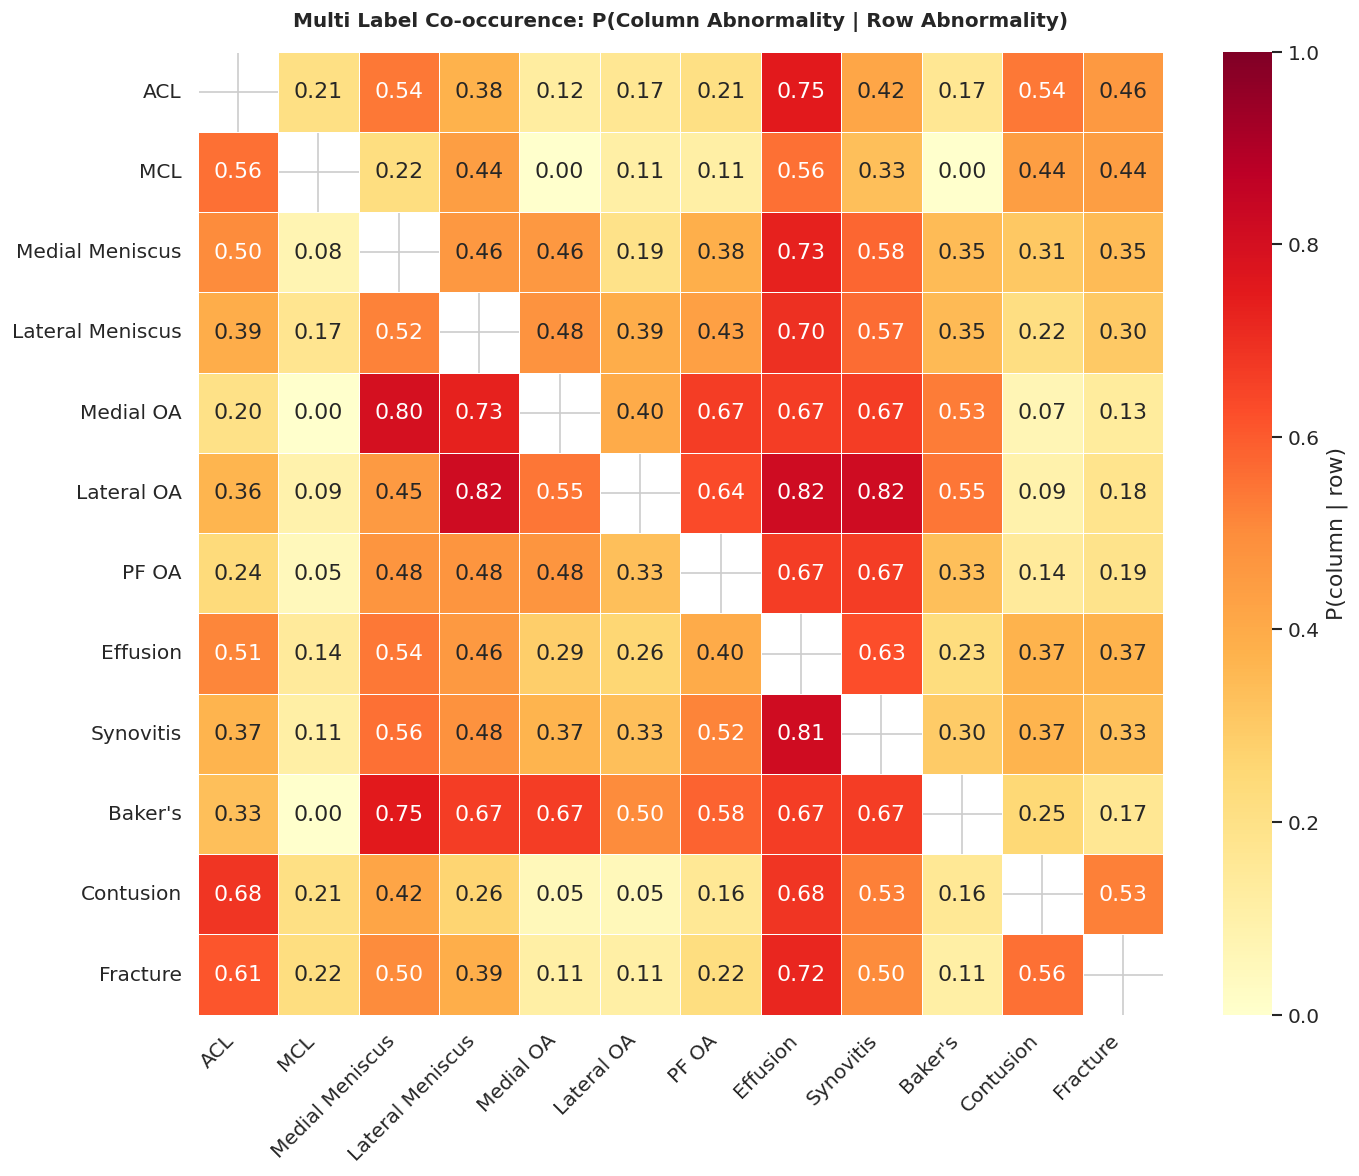

In [6]:
# Co-occurence matrix 
n_targets = len(target_cols)
co_occurence =  np.zeros((n_targets, n_targets))

for i, col_a in enumerate(target_cols):
    for j, col_b in enumerate(target_cols):
        mask = labelled_df[col_a] == 1
        if mask.sum() > 0:
            co_occurence[i, j] = labelled_df.loc[mask, col_b].mean()

fig, ax = plt.subplots(figsize=(12,10))
mask_diag = np.eye(n_targets, dtype=bool)
sns.heatmap(co_occurence, xticklabels=target_cols, yticklabels=target_cols,
           annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, 
           linewidth=0.5, linecolor="white", ax=ax, 
           mask=mask_diag, cbar_kws={'label': 'P(column | row)'})

ax.set_title("Multi Label Co-occurence: P(Column Abnormality | Row Abnormality)",
            fontsize=12, fontweight="bold",pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


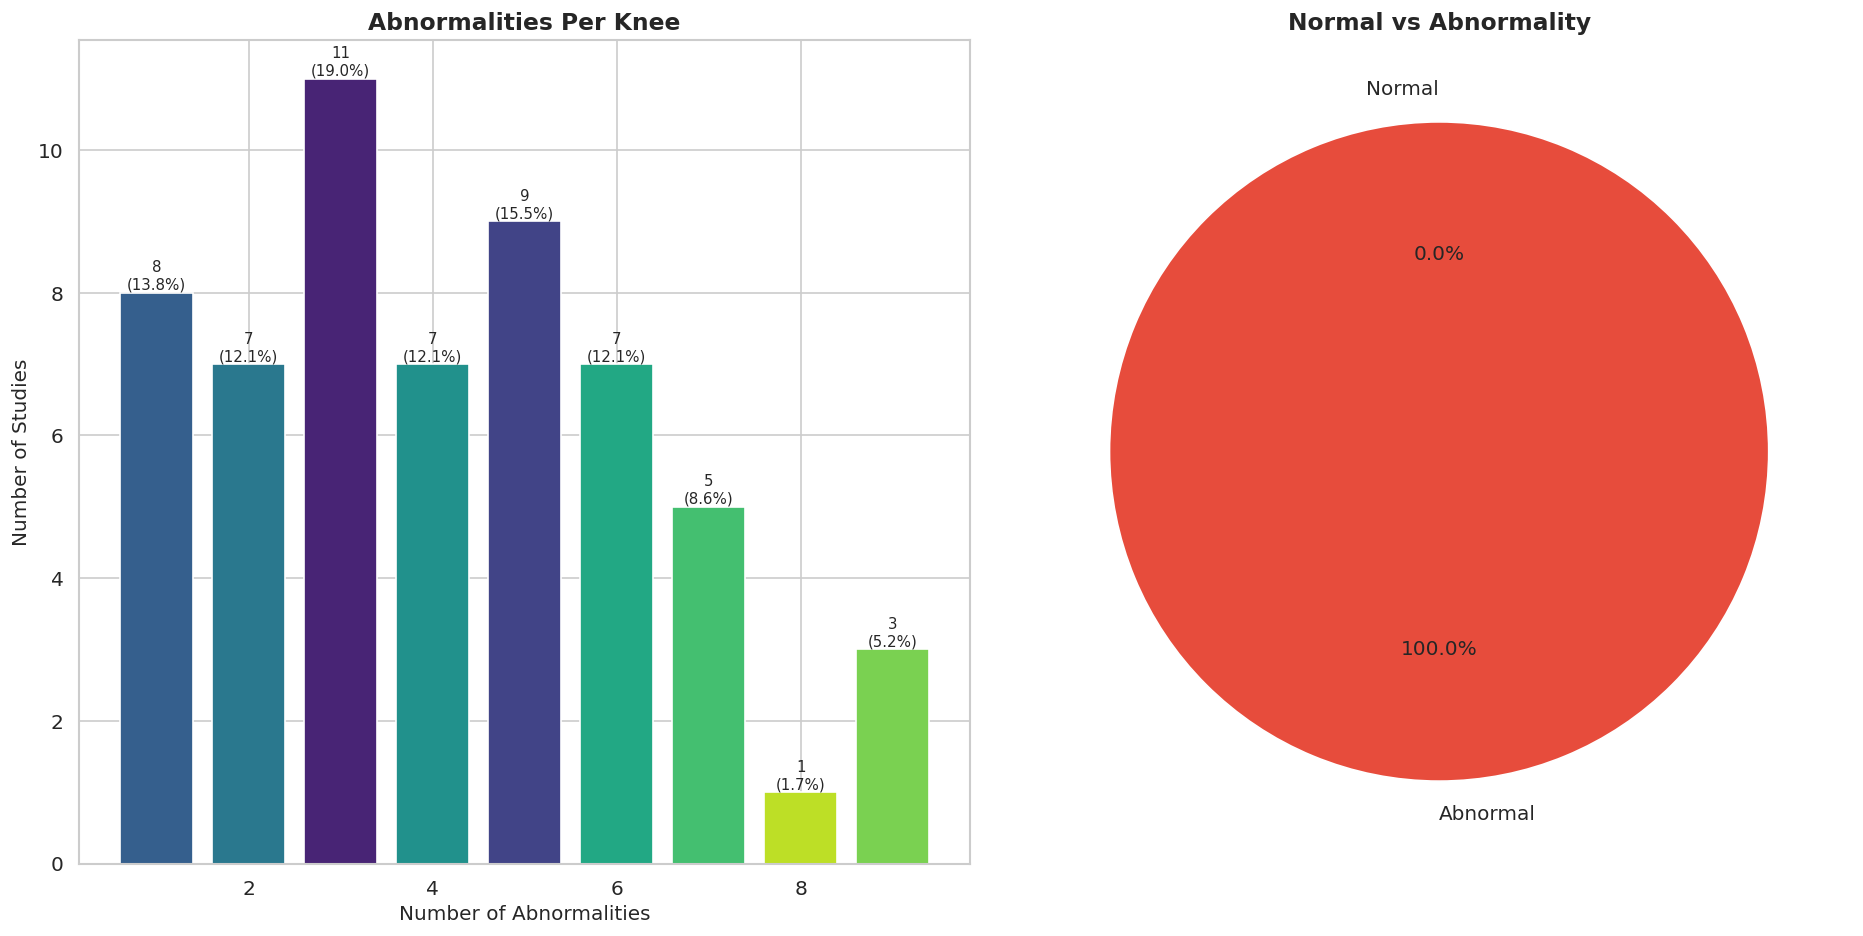

In [7]:
labelled_df["n_abnormalities"] = labelled_df[target_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Distribution of number of abnormalties
counts = labelled_df["n_abnormalities"].value_counts(sort=True)
axes[0].bar(counts.index, counts.values, color=sns.color_palette("viridis", len(counts)), 
           edgecolor="white", linewidth=1)
for x,y in zip(counts.index, counts.values):
    axes[0].text(x, y + 0.05 , f'{y}\n({y/len(labelled_df)*100:.1f}%)', ha='center', fontsize=9)

axes[0].set_xlabel("Number of Abnormalities", fontsize=12)
axes[0].set_ylabel("Number of Studies", fontsize=12)
axes[0].set_title("Abnormalities Per Knee", fontsize=14, fontweight="bold")

# Normal vs Abnormality Check 
has_any = (labelled_df["n_abnormalities"] > 0).sum()
normal = (labelled_df["n_abnormalities"] == 0).sum()
axes[1].pie([normal, has_any], labels=["Normal", "Abnormal"],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title("Normal vs Abnormality", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()